# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Load data from simulation of system dynamic model. 
% Data file contains the variables: model dT t u x z
load readonly/simOut.mat
t = t(1:10000); % crop "t" because simulation is slow; this shortens sim time.
q = [model.k, model.b, model.m]';

% We require the Octave control-systems "package" to implement "expm".
pkg load control

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

### Helper functions for the extended Kalman filter for parameter estimation
The next notebook cells implement the initialization and iteration functions for the EKF for parameter estimation.

In [3]:
% EKF initialization function, called once at the beginning of the simulation
function ekfData = initEKFid(q0,SigmaQ0,SigmaW,SigmaE,u1,x1,dT)
  ekfData.qhat   = q0;      % Initial state description  
  ekfData.SigmaQ = SigmaQ0; % Initial estimation-error covariance 
  ekfData.SigmaE = SigmaE;  % Sensor-noise covariance (on [xk;zk])
  ekfData.SigmaW = SigmaW;  % Process-noise covariance (driving Q)
  ekfData.priorU = u1;      % Previous value of input force
  ekfData.priorX = x1;      % Previous value of state
  ekfData.Qbump  = 5;       % In case SigmaX collapses

  % In MATLAB, we can compute the required derivatives symbolically. Perhaps we can 
  % do this in Octave also, but I don't know how. In MATLAB, we can write:
  %  % Compute the derivative of the output with respect to the parameters
  %  syms k b m x1old x2old uold 
  %  sA = [0 1; -k/m -b/m];
  %  sB = [0; 1/m];
  %  sAd = expm(sA*dT);
  %  sBd = (sA\(sAd-eye(2)))*sB;
  %  sxold = [x1old; x2old];  
  %  sJ = simplify(jacobian(sAd*sxold + sBd*uold,[k b m]));  
  %  ekfData.J = matlabFunction(sJ);
end

In [4]:
% This is the Jacobian function that we need when computing Chat. The terms of the Jacobian
% were computed originally by MATLAB; I copied and pasted them here. As you might imagine,
% this would have been nearly impossible to compute by hand (correctly).
function J = ekfJacobian(b,k,m,uold,x1old,x2old)
  J = zeros(2,3);
  J(1,1) = -(20*uold*(b^2 - 4*k*m)^(3/2) - 10*b^3*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 10*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + 10*b^3*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 10*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + b^2*k*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 4*k^2*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 4*k^3*m*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - b^2*k*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - b^2*k^2*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 4*k^2*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 4*k^3*m*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 40*k^2*m^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b^2*k^2*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 40*k^2*m^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 60*b*k*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b*k^2*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*k^2*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - b*k*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 60*b*k*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 20*b*k^2*m*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - b*k*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + b*k^2*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*k^2*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 20*b*k^2*m*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)))/(20*k^2*(b^2 - 4*k*m)^(3/2));
  J(2,1) = (10*b^2*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 40*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 10*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) - x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) - 10*b^2*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 40*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 10*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + 2*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 20*b*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + b*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 20*b*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2))/(20*(b^2 - 4*k*m)^(3/2));
  J(1,2) = (uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) - k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) - 80*k*m^2*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - b^2*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + 80*k*m^2*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 80*k^2*m^2*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 8*k^2*m^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - b^2*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 80*k^2*m^2*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 8*k^2*m^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + b^2*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 40*b*k*m^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*b^2*k*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b^2*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 40*b*k*m^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*b^2*k*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*b*k*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*b*k*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2))/(40*k*m*(b^2 - 4*k*m)^(3/2));
  J(2,2) = -(2*b^2*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*b^3*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) - 2*b^2*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*b^3*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + 40*b*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*b^2*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 8*k*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 8*k^2*m*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 80*k*m^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*b*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + b^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 2*b^2*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 8*k^2*m*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 80*k*m^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 40*b*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 8*k*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 2*b*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 40*b*k*m*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 8*b*k*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*b*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 40*b*k*m*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 8*b*k*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*b*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2))/(40*m*(b^2 - 4*k*m)^(3/2));
  J(1,3) = -(2*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) - 10*b^3*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + 10*b^3*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) - 2*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) - 20*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + 40*b*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 20*b^2*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*b*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 10*b*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + 2*b*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + b^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + 20*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) - 20*b^2*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 40*b*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 2*b*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 10*b*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) - 2*b*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + 2*b*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*b*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2))/(40*m*(b^2 - 4*k*m)^(3/2));
  J(2,3) = (b^3*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - b^4*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) - b^3*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b^4*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + b^3*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 40*k*m^2*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) - b^3*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 40*k*m^2*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 40*k^2*m^2*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 4*k^2*m^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 40*k^2*m^2*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 4*k^2*m^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + b*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + 4*b*k*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*k^2*m*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 2*k*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 4*b*k*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 4*b*k^2*m*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 20*b*k*m^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 5*b^2*k*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*k*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*k^2*m*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 4*b*k^2*m*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 20*b*k*m^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 5*b^2*k*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + b*k*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + b*k*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2))/(20*m^2*(b^2 - 4*k*m)^(3/2));
end

In [5]:
% EKF iteration function, called once every measurement interval
function [qhat,bounds,ekfData] = iterEKFid(uk,xk,zk,dT,ekfData)
 
  % Get data stored in ekfData structure
  priorU = ekfData.priorU;
  priorX = ekfData.priorX;
  SigmaQ = ekfData.SigmaQ;
  SigmaE = ekfData.SigmaE;
  SigmaW = ekfData.SigmaW;
  qhat   = ekfData.qhat;

  % EKF Step 1a: Parameter prediction time update
  %          - Do nothing. qhat(minus,k) = qhat(plus,k-1)
  
  % EKF Step 1b: Prediction-error covariance time update
  SigmaQ = SigmaQ + SigmaW;
  
  % Step 1c: Output estimate
  k = qhat(1); b = qhat(2); m = qhat(3); 
  A = [0 1; -k/m -b/m]; % Specify continuous-time model
  B = [0; 1/m]; 
  C = [1 0]; 
  Ad = expm(A*dT); Bd = (A\(Ad-eye(2)))*B;  
  dhat = [Ad*priorX + Bd*priorU; C*xk]; % [xk;zk] pred
  
  % Step 2a: Estimator gain matrix
  % In MATLAB, Chat = ekfData.J(b,k,m,priorU,priorX(1),priorX(2));
  Chat = ekfJacobian(b,k,m,priorU,priorX(1),priorX(2));
  Chat = real([Chat; 0 0 0]); % some operations result in tiny imaginary #s

  SigmaD = Chat*SigmaQ*Chat' + SigmaE;
  L = SigmaQ*Chat'/SigmaD;

  % Step 2b: State estimate measurement update
  r = [xk;zk] - dhat; % residual.  Use to check for sensor errors...
  % if r*r' > 100*trace(SigmaD), L(:)=0.0; end 
  qhat = qhat + L*r;

  % Step 2c: Error covariance measurement update
  SigmaQ = SigmaQ - L*SigmaD*L';

  % Q-bump code
  if r*r' > 16*trace(SigmaD) % bad output estimate by 4 std. devs, bump Q 
    fprintf('Bumping SigmaX\n');
    SigmaQ = SigmaQ*ekfData.Qbump;
  end
  [~,S,V] = svd(SigmaQ); % Implement Higham method to help robustness
  HH = V*S*V';
  SigmaQ = (SigmaQ + SigmaQ' + HH + HH')/4; 
  
  % Save data in ekfData structure for next time...
  ekfData.priorU = uk;
  ekfData.priorX = xk;
  ekfData.SigmaQ = SigmaQ;
  ekfData.qhat = qhat;
  bounds = 3*sqrt(diag(SigmaQ));
end

### Implementing the extended Kalman filter for parameter estimation
The next notebook cells implement the main code of the extended Kalman filter.

In [6]:
% Determine number of states and timesteps
[nx,~] = size(x); nt = length(t);

In [7]:
% Reserve storage for computed results, for plotting
nq         = 3; % this many parameters to estimate
qhatstore  = zeros(nq,nt);
boundstore = zeros(nq,nt);

% Covariance values
q0      = [2;1;40];
SigmaQ0 = diag((q-q0)/3)^2; % uncertainty of initial parameters
SigmaW  = diag(1e-8*[1 1 10]);
SigmaE  = blkdiag(model.SigmaW,model.SigmaV);

% Create ekfData structure and initialize variables 
ekfData = initEKFid(q0,SigmaQ0,SigmaW,SigmaE,u(1),x(:,1),dT);

% Now, enter loop for remainder of time, where we update the EKF
% once per sample interval
for k = 2:length(t)
  uk = u(k); % "measure" input force
  xk = x(:,k); % "measure" true state
  zk = z(k); % "measure" nonlinear output
  
  % Update parameters
  [qhatstore(:,k),boundstore(:,k),ekfData] = iterEKFid(uk,xk,zk,dT,ekfData);
  % update waitbar periodically, but not too often (slow procedure)
  if mod(k,2000)==0
    fprintf('Completed %d out of %d iterations\n',k,nt)
  end
end
ekfErr = q - qhatstore;
ekfBnd = boundstore;

Completed 2000 out of 10000 iterations
Completed 4000 out of 10000 iterations
Completed 6000 out of 10000 iterations
Completed 8000 out of 10000 iterations
Completed 10000 out of 10000 iterations


### Plot simulation outputs from the extended Kalman filter
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

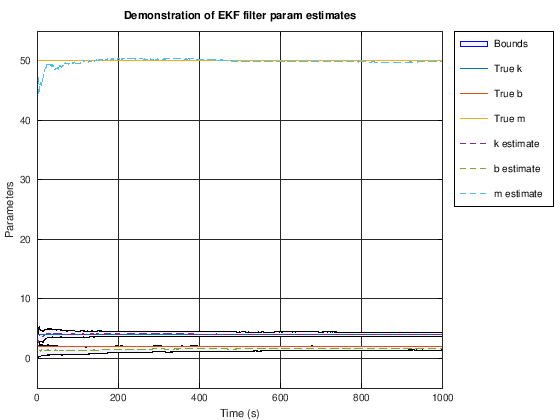

In [14]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [qhatstore-boundstore fliplr(qhatstore+boundstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 

h2 = plot([0 t(end)],[q,q],t,qhatstore','--'); ylim([-5 55]);
legend([h2;h1a],{'True k','True b','True m','k estimate',...
  'b estimate','m estimate','Bounds'},"Location","bestoutside"); 
title('Demonstration of EKF filter param estimates'); 
xlabel('Time (s)'); ylabel('Parameters'); 

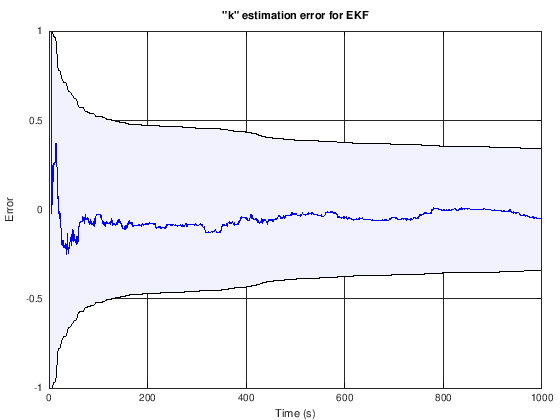

In [15]:
fill([t fliplr(t)],[-boundstore(1,:) fliplr(boundstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ekfErr(1,:),'b'); ylim([-1 1])
title('"k" estimation error for EKF'); 
xlabel('Time (s)'); ylabel('Error'); 

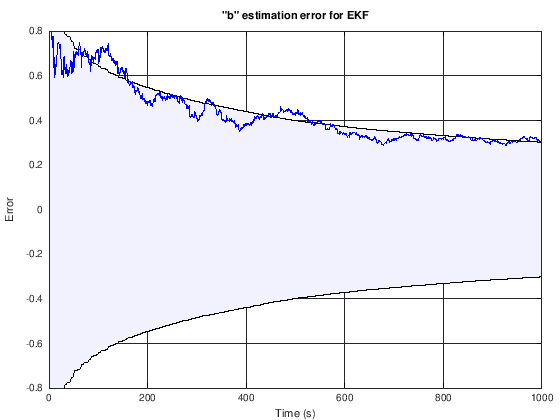

In [16]:
fill([t fliplr(t)],[-boundstore(2,:) fliplr(boundstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ekfErr(2,:),'b'); ylim([-0.8 0.8])
title('"b" estimation error for EKF'); 
xlabel('Time (s)'); ylabel('Error'); 

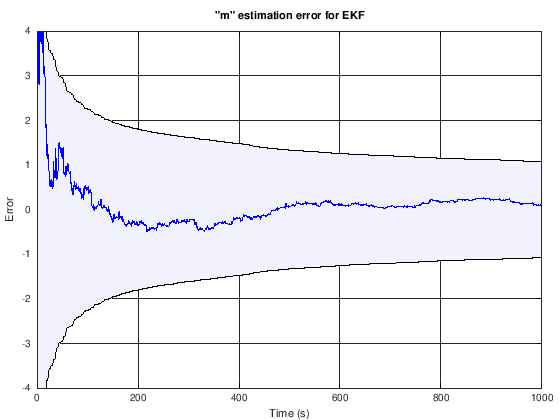

In [17]:
fill([t fliplr(t)],[-boundstore(3,:) fliplr(boundstore(3,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ekfErr(3,:),'b'); ylim([-4 4])
title('"m" estimation error for EKF'); 
xlabel('Time (s)'); ylabel('Error'); 

In [18]:
% Compute and output some statistics
fprintf('RMS parameter estimation error = %g\n',rms(ekfErr(:)));
ind = find(abs(ekfErr(:))>boundstore(:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundstore(:))*100);

RMS parameter estimation error = 0.562688
Time error outside bounds = 9.85%


In [19]:
% Compute and output some statistics
fprintf('RMS parameter estimation error = %g\n',rms(ekfErr(2,:)));
ind = find(abs(ekfErr(2,:))>boundstore(2,:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundstore(2,:))*100);

RMS parameter estimation error = 0.447103
Time error outside bounds = 29.34%


In [20]:
% Compute and output some statistics
fprintf('RMS parameter estimation error = %g\n',rms(ekfErr(3,:)));
ind = find(abs(ekfErr(3,:))>boundstore(3,:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundstore(3,:))*100);

RMS parameter estimation error = 0.85391
Time error outside bounds = 0.11%
